# **SEASONAL FLU VACCINE PREDICTION:**
## **FINAL NOTEBOOK.**

#### **Notebook Purpose:**
This notebook presents the complete end to end machine learning pipeline for predicting seasonal flu vaccination. It follows the CRISP-DM framework which is an iterative data science process. Each stage informs then next and findings from later stages which may cause us to revisit earlier ones.

The iterative nature of this process is deliberately shown throughout this notebook e.g evaluation rsuts inform modelling decisions and modelling decisions refernce back to data preparation choices.

#### **CRISP-DM Framework: Complete Pipeline.**



| Stage | What We Do | Section |

1. **Business Understanding** | Define stakeholder, problem statement and why ML | Section 1 |

2. **Data Understanding** | Load cleaned data, summarize key findings from analysis | Section 2 |

3. **Data Preparation** | Drop features, split, impute, scale, encode | Section 3 |

4. **Modeling** | Build baseline, tuned and ensemble models iteratively | Section 4 |

5. **Evaluation** | Evaluate models, select best, identify limitations | Section 5 |

6. **Deployment** | Recommendations for stakeholders and next steps | Section 6 |


#### **Data Source:** National 2009 H1N1 Flu Survey.


#### **Notebook Inputs:**
- `Data/Cleaned_data/cleaned_data.csv`

#### **Notebook Outputs:**
- `Data/Cleaned_data/processed_data.csv`
- Trained classification models
- Evaluation metrics and recommendations

### **BUSINESS UNDERSTANING.**

#### **Background:**

The 2009 H1N1 influenza pandemic, commonly known as "swine flu", 
swept across the world beginning in spring 2009, responsible for 
an estimated 151,000 to 575,000 deaths globally in its first year. 
In response, the United States government launched a vaccination 
campaign making H1N1 vaccines publicly available in October 2009.

In late 2009 and early 2010, the United States conducted the 
National 2009 H1N1 Flu Survey to monitor vaccination rates. 
This phone survey asked respondents whether they had received 
H1N1 and seasonal flu vaccines alongside questions about their 
backgrounds, opinions, and health behaviors.

**Note on Context:** While this dataset originates from the 2009 
US H1N1 Flu Survey, the behavioral, opinion, and demographic 
drivers of vaccine hesitancy are universal public health phenomena. 
The methodology and insights generated are directly applicable to 
the Kenyan public health context, particularly given Kenya's 
ongoing challenges with seasonal influenza vaccination uptake. 
Kenya experiences two flu seasons annually, March to May and 
October to December, aligned with the long and short rains, 
making seasonal flu vaccination a recurring and critical public 
health challenge.

#### **Stakeholders:**

This project adopts a dual - level stakeholder framework reflecting real epidemiological practice, where population-level patterns inform facility-level interventions. Our stakeholders operate within the Kenyan public health system:

**|Stakeholder | Role | What They Need |**

**|County Director of Health (CDoH) |** Responsible for public health Surveillance and community reach at County Level | Identify which communities to target for seasonal flu vaccination outreach every flu season |

**|Chief Executive Officers: Kenyatta Referral Hospital $ Mbagathi County Hospital|** Responsible for clinical interventions in public hospitals | Identify which patients to flag for additional encouragement from clinicians during consultations |


#### **Business Problem:**

Can we predict whether an individual will receive the seasonal flu vaccine based on their background, opinions, and health behaviors?

Understanding the drivers of seasonal flu vaccination uptake will allow our stakeholders to:

- **County Director of Health:** Use demographic and behavioral patterns to target community outreach programs at popualtions with consistently low vaccination rates every flu season, ensuring more effecient allocation of public health resources.

- **County Referall Hospital CEOs:** Use clinical predictors such as chronic medical conditions, doctor recommendations and health insuarance status to identify and proactively engage patients who are unlikely to vaccinate during routine clinical consultations.


#### **Why Machine Learning?**

Traditional surveys can often pinpoint and tell us vaccination rates but cannot predict future or identify at-risk individuals before vaccination campaigns begin.

A classification model allows us to :
- Predict seasonal flu vaccination likelihood for new individuals.
- Identify the most important drivers of vaccination behavior.
- Generate actionable and specific recommendations for both 
  community outreach and clinical intervention.
- Move from descriptive analysis to predictive intervention.
- Build a reusable framework that remains relevant every flu season.

#### **Project Scope:**

-  **Target Variable** : `seasonal_vaccine` only (binary: 0 = not vaccinated, 1 = vaccinated) 
-  **In Scope** : Predicting seasonal flu vaccination behavior 
-  **Out of Scope** : Predicting H1N1 vaccination, real-time prediction, causal inference 
- **Success Metric** : ROC AUC score 
- **Context** : Methodology adapted from US 2009 H1N1 Flu Survey for Kenyan public health setting 

### **DATA UNDERSTANDING:**

### **Dataset Description:**
The dataset comes from the National 2009 H1N1 Flu Survey conducted 
by the United States government. We are working with four files:

-  `training_set_features.csv` : 35 features for survey respondents | 26,707 |
-  `training_set_labels.csv` : Target variables for survey respondents | 26,707 | seasonal_vaccine only |
-  `test_set_features.csv` : Features for unseen respondents | 26,708 | 
-  `submission_format.csv` : Competition submission template | 26,708 |

My main focus is the  `training_set_features.csv` and `training_set_labels.csv`, this is because the  `test_set_features.csv` dataset has unseen data that was needed for the competition submission file while `submission_format.csv` is purely for the competition submission format.

### **Data Cleaning and Anaylsis:**

This notebook is the third and final in a series of three notebooks that form our complete data science pipeline. The full pipeline is documented as follows:

| Notebook | Purpose | Key Output |

| `01_Data_cleaning.ipynb` | Business understanding, data understanding, duplicate removal, missing values visualization | `cleaned_data.csv` |

| `02_Analysis.ipynb` | Exploratory data analysis, feature distributions, outlier detection, feature vs target analysis, correlation analysis, feature selection decisions | Visualizations and feature selection summary |

| `03_Final_notebook.ipynb` | Complete ML pipeline, modeling, evaluation and recommendations | `processed_data.csv`, trained models, stakeholder recommendations |

#### **Summary and Links to Previous Notebooks:**

#### **Data Cleaning:**

**Link:** [01_Data_cleaning.ipynb](../Notebooks/01_Data_cleaning.ipynb)

- Dataset contains **26,707 respondents** and **36 columns**
- Target variable is `seasonal_vaccine` (binary: 0 = not vaccinated, 1 = vaccinated)
- Class balance is approximately **53% not vaccinated** and **47% vaccinated** - no resampling needed
- **No duplicate rows** were found
- **30 out of 36 columns** have missing values
- Three critical columns have more than 45% missing values:
    - `employment_occupation` (50.44%)
    - `employment_industry` (49.91%)
    - `health_insurance` (45.96%)
- Missing value treatment deferred to this notebook 
  after train test split to prevent data leakage

#### **Analysis:**

**Link:** [02_Analysis.ipynb](Notebooks/02_Analysis.ipynb)

- **Opinion features** are the strongest predictors 
  of seasonal vaccination:
    - `opinion_seas_risk` (r = 0.390)
    - `doctor_recc_seasonal` (r = 0.369)
    - `opinion_seas_vacc_effective` (r = 0.362)
- **Doctor recommendation** is the second strongest 
  predictor confirming importance of clinical interventions
- **Age group** is the strongest demographic predictor — 
  65+ years: 67.4% vaccinated vs 18-34 years: 28.5%
- **Uncertainty** about vaccine side effects (Don't know) 
  is a bigger barrier than actual worry
- **14 features identified for removal** based on being 
  H1N1 specific, having negligible predictive power, 
  excessive missing values or not being transferable 
  to the Kenyan context
- **No severe multicollinearity** detected between 
  seasonal focus features
- **No true outliers** detected — flagged values are 
  legitimate survey responses


#### **Data Loading and Data Summary:**


In [8]:
#IMPORTING LIBRARIES TO BE USED DURING THE WHOLE NOTEBOOK

#Standard Libraries
import warnings
warnings.filterwarnings("ignore")

#Core Libraries
import numpy as np
import pandas as pd

#Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

#Scikit-Learn Libraries
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    LabelEncoder
)

#Scikit-Learn Imputation Libraries
from sklearn.impute import SimpleImputer

#Scikit-learn Model Selection Libraries
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV,
    StratifiedKFold
)

#Scikit-Learn Models
from sklearn.linear_model import (
    LogisticRegression,
    Ridge,
    Lasso
)

#Decision Tree Models
from sklearn.tree import DecisionTreeClassifier, plot_tree

#Scikit-Learn Pipelines
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer

#Ensmble Models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
)

#Scikit-Learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

#Statsmodels Libraries
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Display Settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

#Random seed for reproducibility across all models and splits

RANDOM_STATE = 42

print ("All Libraries are imported successfuly and ready to use")



All Libraries are imported successfuly and ready to use


In [9]:
#Loading and viewing the Cleaned data:

cleaned_path = "../Data/Cleaned_data/"
images_path = "../Images/"

df = pd.read_csv(
    cleaned_path + "cleaned_data.csv",
    index_col="respondent_id"
)

print(f" Cleaned data loaded successfully")
print(f"  Shape : {df.shape}")
df.head(5)

 Cleaned data loaded successfully
  Shape : (26707, 36)


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0


In [10]:
#Quick data Understanding summary:

print("Data Understanding Summary")
print(f"Rows              : {df.shape[0]}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicates        : {df.duplicated().sum()}")
print(f"\nClass Balance:")
print(f"Not Vaccinated (0): {(df['seasonal_vaccine']==0).sum()} ({(df['seasonal_vaccine']==0).mean():.1%})")
print(f"Vaccinated     (1): {(df['seasonal_vaccine']==1).sum()} ({(df['seasonal_vaccine']==1).mean():.1%})")

Data Understanding Summary
Rows              : 26707
Columns           : 36
Missing Values    : 60762
Duplicates        : 0

Class Balance:
Not Vaccinated (0): 14272 (53.4%)
Vaccinated     (1): 12435 (46.6%)


### **DATA PREPARATION:**


In this section we prepare our cleaned data for machine 
learning modeling. This section is the most critical in 
terms of preventing data leakage and ensuring our model 
performance on test data realistically represents how it 
would perform on truly unseen data.

### Why Order Matters
The order of operations in this section is deliberate 
and follows best practices for machine learning:
```
Load Cleaned Data
        ↓
Drop Irrelevant Features        ← safe on full dataset
                                   no statistics calculated
                                   just removing columns
        ↓
Define Features and Target      ← separate X and y
        ↓
Train Test Split                ← split BEFORE any transformation
                                   test set is locked away
                                   never used for fitting
        ↓
Visualize Missing Values        ← on training set only
Before Treatment                   just visualization
                                   no changes to data
        ↓
Preprocessing Pipeline          ← fit on training set ONLY
  ├── Numeric Features              then transform both
  │   ├── Median Imputation         train and test sets
  │   └── Standard Scaling          separately
  └── Categorical Features
      ├── Most Frequent Imputation
      └── One Hot Encoding
        ↓
Visualize Missing Values        ← confirm no missing values
After Treatment                    remain after imputation
        ↓
Save Processed Data             ← save for reference
```

### Key Data Leakage Prevention Decisions

| Decision | Reason |

| Drop columns before splitting | Dropping columns does not involve calculating any statistics from the data so it is safe to do on the full dataset |

| Split before imputing | If we imputed on the full dataset the test set values would influence the median used to fill training data — that is leakage |

| Split before scaling | If we scaled on the full dataset the test set values would influence the mean and standard deviation used to scale training data — that is leakage |

| Split before encoding | If we encoded on the full dataset the test set categories would influence the encoding applied to training data — that is leakage |

| Fit preprocessor on train only | The preprocessor learns statistics from training data only then applies those same statistics to transform the test set |

| Transform test with train statistics | The test set is transformed using the median, mean, standard deviation and categories learned from the training set only |

### What Goes Into the Pipeline

**Numeric Features:**
- `SimpleImputer(strategy="median")` - median imputation 
  is preferred over mean as it is robust to the skewed 
  distributions and outliers observed in our numeric 
  features during analysis i.e. if most peaople scored 4 on opinion_seas_risk and a few scored very low, the mean would be pulled down by those low scores giving us a misleading fill value. The median ignores those extremes and gives us the true middle value.

  And for our categorical values most frequent imputation preserves the natural distribution by filing missing values with the most common category rather than introducing a new category. E.g. for somthing like employment status the safest assumption is that amissing value most likely belongs to the most common category which can be employes, unemployed or not in Labour force.

- `StandardScaler()` - scales features to zero mean and 
  unit variance, required for distance based models like 
  Logistic Regression with regularization

**Categorical Features:**
- `SimpleImputer(strategy="most_frequent")` - most frequent 
  imputation preserves the natural distribution of 
  categorical features by filling missing values with 
  the most common category rather than introducing 
  a new artificial category
- `OneHotEncoder(handle_unknown="ignore")` - converts 
  categorical variables to binary columns, one per 
  category. handle_unknown="ignore" ensures unseen 
  categories in test set do not cause errors

#### **Drop Irrelevant Features:**
Based on our analysis notebook findings we drop features 
that are either:
- H1N1 specific and out of scope
- Have negligible predictive power
- Have too many missing values
- Contain random string identifiers
- Not transferable to the Kenyan context

In [11]:
#Drop Irrelevant columns that won't be used in modelling

# Features to drop based on analysis notebook findings
cols_to_drop = [
    # H1N1 specific features - out of scope
    "h1n1_concern",
    "h1n1_knowledge",
    "doctor_recc_h1n1",
    "opinion_h1n1_vacc_effective",
    "opinion_h1n1_risk",
    "opinion_h1n1_sick_from_vacc",
    # Negligible predictive power
    "behavioral_antiviral_meds",
    "child_under_6_months",
    # Too many missing values and random strings
    "hhs_geo_region",
    "employment_industry",
    "employment_occupation",
    "census_msa",
    # Not transferable to Kenyan context
    "race",
    # Weak predictor
    "household_adults"
]

# Defensive drop - only drop columns that exist also so that an error doesn't occur when rerunning these cells later.
cols_to_drop = [col for col in cols_to_drop if col in df.columns]
df = df.drop(columns=cols_to_drop)

print(f" Dropped {len(cols_to_drop)} irrelevant features")
print(f"  Remaining columns : {df.shape[1]}")
print(f"  Remaining shape   : {df.shape}")

 Dropped 14 irrelevant features
  Remaining columns : 22
  Remaining shape   : (26707, 22)


#### **Define features and Target:**


In [12]:
#Defining Features and Target Variable:

# Separate features and target
X = df.drop(columns=["seasonal_vaccine"])
y = df["seasonal_vaccine"]

# Separate numeric and categorical columns
# Exclude target variable to prevent data leakage during preprocessing
numeric_features = X.select_dtypes(
    include=["float64", "int64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print(f" Features and target defined")
print(f"  Total Features       : {X.shape[1]}")
print(f"  Numeric Features     : {len(numeric_features)}")
for col in numeric_features:
    print(f"    - {col}")
print(f"\n  Categorical Features : {len(categorical_features)}")
for col in categorical_features:
    print(f"    - {col}")
print(f"\n  Target               : seasonal_vaccine")

 Features and target defined
  Total Features       : 21
  Numeric Features     : 14
    - behavioral_avoidance
    - behavioral_face_mask
    - behavioral_wash_hands
    - behavioral_large_gatherings
    - behavioral_outside_home
    - behavioral_touch_face
    - doctor_recc_seasonal
    - chronic_med_condition
    - health_worker
    - health_insurance
    - opinion_seas_vacc_effective
    - opinion_seas_risk
    - opinion_seas_sick_from_vacc
    - household_children

  Categorical Features : 7
    - age_group
    - education
    - sex
    - income_poverty
    - marital_status
    - rent_or_own
    - employment_status

  Target               : seasonal_vaccine


#### **Train Test Split:**

I split the data before any imputation, scaling or encoding to prevent data leakage. I used stratified splitting to maintain class balance in both sets where a test size of 20% gives 5,341 samples for evaluation which is sufficient for extensive modell assesment.

In [13]:
#Split data and ensured to stratify on target to mainatin class balance.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y)

#Stratification above was done to maintain a balanced class

print("Train test split completed")
print(f"\n  Training set   : {X_train.shape}")
print(f"  Test set       : {X_test.shape}")
print(f"\n  Class Balance Check:")
print(f"  Train - Not Vaccinated : {(y_train==0).sum()} ({(y_train==0).mean():.1%})")
print(f"  Train - Vaccinated     : {(y_train==1).sum()} ({(y_train==1).mean():.1%})")
print(f"  Test  - Not Vaccinated : {(y_test==0).sum()} ({(y_test==0).mean():.1%})")
print(f"  Test  - Vaccinated     : {(y_test==1).sum()} ({(y_test==1).mean():.1%})")

Train test split completed

  Training set   : (21365, 21)
  Test set       : (5342, 21)

  Class Balance Check:
  Train - Not Vaccinated : 11417 (53.4%)
  Train - Vaccinated     : 9948 (46.6%)
  Test  - Not Vaccinated : 2855 (53.4%)
  Test  - Vaccinated     : 2487 (46.6%)


#### **Missing Values - Before Treatment**

I visualized missing values in the training set only. This confirmed missing values exist before imputation and demonstrates I am treating train and test separately to prevent data leakage.

Columns with missing values in training set: 19


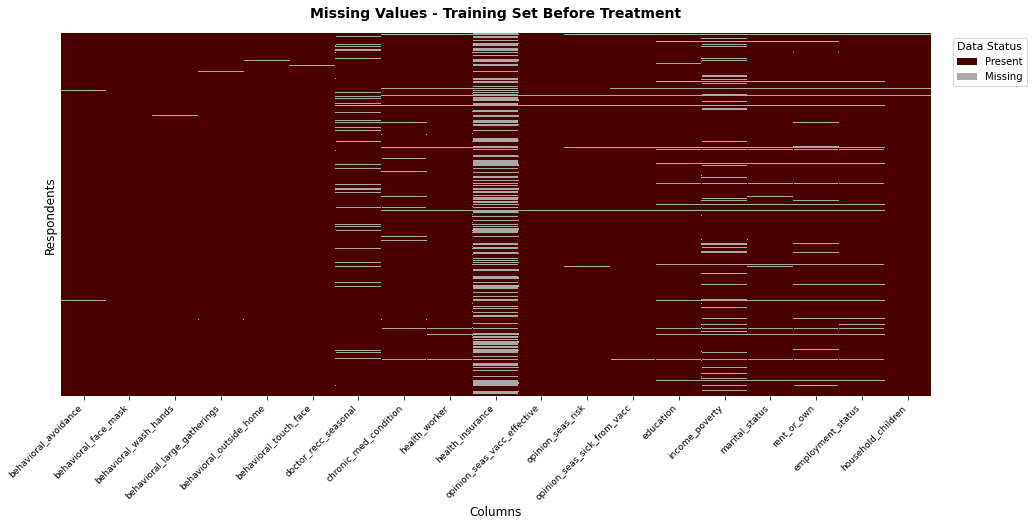

In [14]:
#Missing Values Heatmap
#Before Treatment

custom_cmap = ListedColormap(["#4A0000", "#A9A9A9"])

# Show missing values in training set only
missing_cols = X_train.columns[X_train.isnull().any()].tolist()

print(f"Columns with missing values in training set: {len(missing_cols)}")

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    X_train[missing_cols].isnull(),
    yticklabels=False,
    cbar=False,
    cmap=custom_cmap,
    ax=ax
)

ax.set_title(
    "Missing Values - Training Set Before Treatment",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Columns", fontsize=12)
ax.set_ylabel("Respondents", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=9)

legend_elements = [
    Patch(facecolor="#4A0000", label="Present"),
    Patch(facecolor="#A9A9A9", label="Missing")
]
ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Data Status",
    title_fontsize=11,
    frameon=True
)

plt.subplots_adjust(bottom=0.25, right=0.88)
plt.savefig(images_path + "missing_values_train_before.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### **Preprocessing:**

I built a single preprocessing pipeline that:

- Imputes missing numeric values using median strategy
- Imputes missing categorical values using most frequent strategy
- Scales numeric features using StandardScaler
- Encodes categorical features using OneHotEncoder
- Fits ONLY on training data and transforms both 
  train and test sets to prevent data leakage

In [ ]:
#Preprocessing pipeline

# Numeric pipeline - impute missing values then scale: used the median impuatation as its robust to outliers
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical pipeline - impute missing values then encode used the most frequent imputation startegy
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown = "ignore", sparse = False))
])

# Combine numeric and categorical pipelines
# Fit on training data only to prevent data leakage
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

# Fit on training data only and transform both sets
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f" Preprocessing pipeline completed")
print(f"  X_train_processed shape : {X_train_processed.shape}")
print(f"  X_test_processed shape  : {X_test_processed.shape}")

 Preprocessing pipeline completed
  X_train_processed shape : (21365, 35)
  X_test_processed shape  : (5342, 35)


#### **Missing Values - After Treatment:**

✓ Missing values after treatment: 0


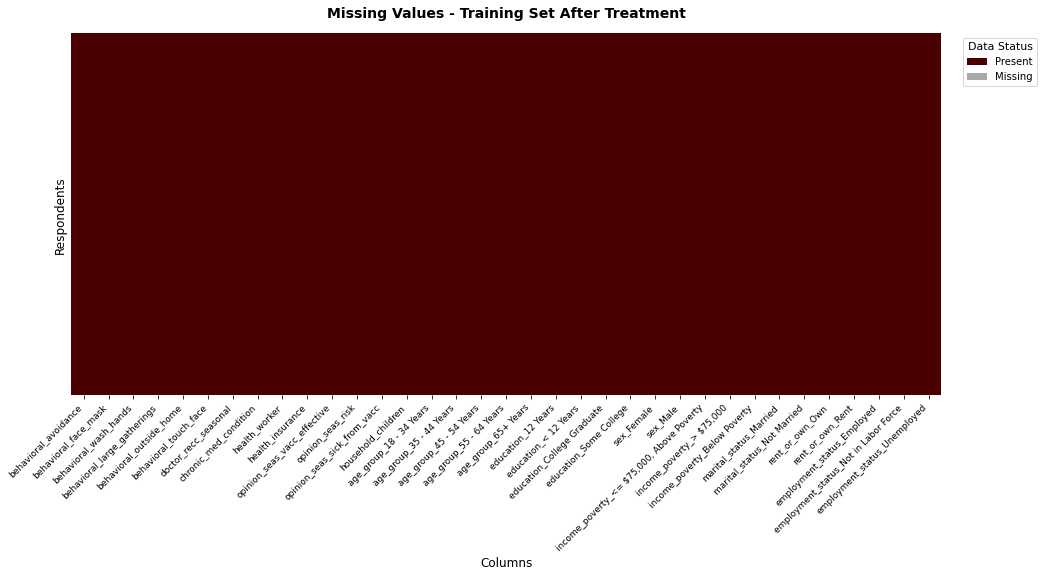

In [18]:
#Missing Value heatmap after treatment

# Get feature names manually(Because i am using an older version of sci-kit learn)
numeric_feature_names = numeric_features

# Get categorical feature names after one hot encoding
categorical_feature_names = preprocessor\
    .named_transformers_["categorical"]\
    .named_steps["encoder"]\
    .get_feature_names(categorical_features)\
    .tolist()

# Combine all feature names
all_feature_names = numeric_feature_names + categorical_feature_names

# Convert processed array back to dataframe for visualization
X_train_df = pd.DataFrame(
    X_train_processed,
    columns=all_feature_names
)

# Confirm no missing values remain
missing_after = X_train_df.isnull().sum().sum()
print(f"✓ Missing values after treatment: {missing_after}")

fig, ax = plt.subplots(figsize=(16, 8))

sns.heatmap(
    X_train_df.isnull(),
    yticklabels=False,
    cbar=False,
    cmap=custom_cmap,
    ax=ax
)

ax.set_title(
    "Missing Values - Training Set After Treatment",
    fontsize=14, fontweight="bold", pad=15
)
ax.set_xlabel("Columns", fontsize=12)
ax.set_ylabel("Respondents", fontsize=12)

plt.xticks(rotation=45, ha="right", fontsize=9)

ax.legend(
    handles=legend_elements,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    fontsize=10,
    title="Data Status",
    title_fontsize=11,
    frameon=True
)

plt.subplots_adjust(bottom=0.25, right=0.88)
plt.savefig(images_path + "missing_values_train_after.png",
            dpi=150, bbox_inches="tight")
plt.show()

#### **Save Processed Data:**


In [20]:
#Saving the Processed data to the Cleaned_data folder

X_train_df["seasonal_vaccine"] = y_train.values
X_train_df.to_csv(
    cleaned_path + "processed_data.csv",
    index=False
)

print(f" Processed data saved successfully")
print(f"  Location : {cleaned_path}processed_data.csv")
print(f"  Shape    : {X_train_df.shape}")


 Processed data saved successfully
  Location : ../Data/Cleaned_data/processed_data.csv
  Shape    : (21365, 36)
